In [1]:
import random
import numpy as np
import tensorflow as tf

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [2]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
from pathlib import Path
import zipfile
from PIL import Image
import os

In [3]:
ZIP_PATH = "/content/drive/MyDrive/CNN_Cats_Dogs/kagglecatsanddogs_5340.zip"
DATA_DIR = "/content/cats_dogs_data"
IMG_SIZE = 160
MAX_IMAGES_PER_CLASS = 4000

In [4]:
def load_cats_dogs(zip_path=ZIP_PATH, data_dir=DATA_DIR, img_size=IMG_SIZE, max_per_class=MAX_IMAGES_PER_CLASS):
    if Path(data_dir).exists() is False:
        with zipfile.ZipFile(zip_path, 'r') as z:
            z.extractall(data_dir)

    base = Path(data_dir) / 'PetImages'
    X, y = [], []

    for label, folder in enumerate(['Cat', 'Dog']):
        folder_path = base / folder
        if not folder_path.exists():
            continue

        count = 0
        for img_path in sorted(folder_path.glob('*.jpg')):
            if count >= max_per_class:
                break
            try:
                img = Image.open(img_path).convert('RGB').resize((img_size, img_size))
                X.append(np.array(img))
                y.append(label)
                count += 1
            except Exception:
                pass

    return np.array(X), np.array(y)

X_raw, y = load_cats_dogs()
print(f"Charge : {X_raw.shape[0]} images, forme {X_raw.shape[1:]}")
print(f"Classes : Chat=0, Chien=1 | Effectifs : Chat={np.sum(y==0)}, Chien={np.sum(y==1)}")

Charge : 8000 images, forme (160, 160, 3)
Classes : Chat=0, Chien=1 | Effectifs : Chat=4000, Chien=4000


In [5]:
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

X = preprocess_input(X_raw.astype(np.float32))
print(f"Shape apres preprocess_input : {X.shape}")

X = X_raw.astype(np.float32) / 255.0
print(f"Plage des pixels apres normalisation : [{X.min():.2f}, {X.max():.2f}]")

Shape apres preprocess_input : (8000, 160, 160, 3)
Plage des pixels apres normalisation : [0.00, 1.00]


In [6]:
from sklearn.model_selection import train_test_split

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, stratify=y, random_state=42
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.2, stratify=y_temp, random_state=42
)

print(f"Train : {len(X_train)} | Val : {len(X_val)} | Test : {len(X_test)}")

Train : 5440 | Val : 1360 | Test : 1200


In [7]:
IMG_SIZE = 160
MAX_IMAGES_PER_CLASS = 4000

EXP_NAME = "Exp17_MobileNetV2_Frozen"

LEARNING_RATE = 0.0001
EPOCHS = 15
BATCH_SIZE = 32

PATIENCE_EARLYSTOP = 4
PATIENCE_REDUCE_LR = 2
REDUCE_FACTOR = 0.5

SAVE_DIR = "/content/drive/MyDrive/CNN_Cats_Dogs"
os.makedirs(SAVE_DIR, exist_ok=True)

In [8]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models
import tensorflow as tf

base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

base_model.trainable = False

model = models.Sequential([
    layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.2),
    layers.Dense(1, activation="sigmoid")
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_160            │ (None, 5, 5, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [9]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=PATIENCE_EARLYSTOP,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=REDUCE_FACTOR,
    patience=PATIENCE_REDUCE_LR,
    min_lr=1e-6,
    verbose=1
)

checkpoint = tf.keras.callbacks.ModelCheckpoint(
    f"{SAVE_DIR}/{EXP_NAME}_best.keras",
    monitor="val_loss",
    save_best_only=True,
    mode="min",
    verbose=1
)

In [10]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rotation_range=5,
    width_shift_range=0.03,
    height_shift_range=0.03,
    zoom_range=0.03,
    horizontal_flip=True,
    fill_mode="nearest"
)

In [11]:
import time
import math

steps_per_epoch = math.ceil(len(X_train) / BATCH_SIZE)

start_time = time.time()

history = model.fit(
    datagen.flow(X_train, y_train, batch_size=BATCH_SIZE, shuffle=True),
    epochs=EPOCHS,
    steps_per_epoch=steps_per_epoch,
    validation_data=(X_val, y_val),
    callbacks=[early_stop, reduce_lr, checkpoint],
    verbose=1
)

training_time = round(time.time() - start_time, 2)
print("Temps d'entraînement :", training_time, "s")

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/15
170/170 ━━━━━━━━━━━━━━━━━━━━ 0s 460ms/step - accuracy: 0.5584 - loss: 0.8165
Epoch 1: val_loss improved from inf to 0.35329, saving model to /content/drive/MyDrive/CNN_Cats_Dogs/Exp17_MobileNetV2_Frozen_best.keras
170/170 ━━━━━━━━━━━━━━━━━━━━ 105s 597ms/step - accuracy: 0.5591 - loss: 0.8155 - val_accuracy: 0.8934 - val_loss: 0.3533 - learning_rate: 1.0000e-04
Epoch 2/15
170/170 ━━━━━━━━━━━━━━━━━━━━ 0s 449ms/step - accuracy: 0.8712 - loss: 0.3418
Epoch 2: val_loss improved from 0.35329 to 0.21515, saving model to /content/drive/MyDrive/CNN_Cats_Dogs/Exp17_MobileNetV2_Frozen_best.keras
170/170 ━━━━━━━━━━━━━━━━━━━━ 98s 573ms/step - accuracy: 0.8713 - loss: 0.3415 - val_accuracy: 0.9397 - val_loss: 0.2151 - learning_rate: 1.0000e-04
Epoch 3/15
170/170 ━━━━━━━━━━━━━━━━━━━━ 0s 442ms/step - accuracy: 0.9307 - loss: 0.2178
Epoch 3: val_loss improved from 0.21515 to 0.16515, saving model to /content/drive/MyDrive/CNN_Cats_Dogs/Exp17_MobileNetV2_Frozen_best.keras
170/170 ━━━━━━━━━━━━

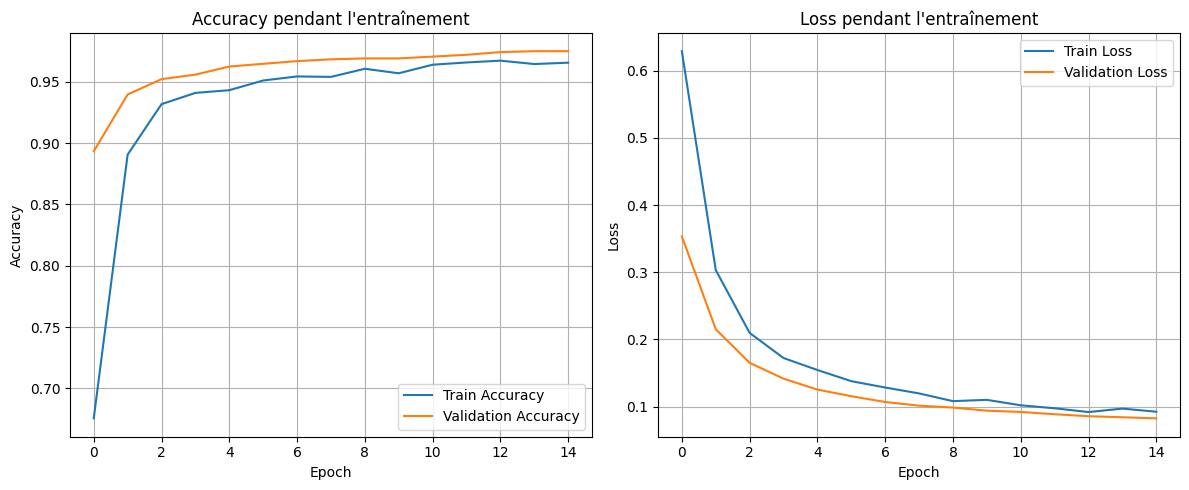

In [12]:
plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title("Accuracy pendant l'entraînement")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("Loss pendant l'entraînement")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [13]:
from sklearn.metrics import f1_score
import numpy as np

best_model = tf.keras.models.load_model(f"{SAVE_DIR}/{EXP_NAME}_best.keras")

test_loss, test_acc = best_model.evaluate(X_test, y_test, verbose=0)
print(f"✅ Test accuracy (BEST checkpoint) : {test_acc*100:.2f}%")

y_pred = (best_model.predict(X_test) > 0.5).astype(int).flatten()

f1 = f1_score(y_test, y_pred, average='macro')
erreurs = int(np.sum(y_pred != y_test))

print(f"F1-score (macro) : {f1:.3f}")
print(f"Erreurs totales : {erreurs}")

✅ Test accuracy (BEST checkpoint) : 96.83%
38/38 ━━━━━━━━━━━━━━━━━━━━ 15s 374ms/step
F1-score (macro) : 0.968
Erreurs totales : 38


In [14]:
best_model = tf.keras.models.load_model(f"{SAVE_DIR}/{EXP_NAME}_best.keras")

test_loss, test_acc = best_model.evaluate(X_test, y_test, verbose=0)
print(f"✅ Test accuracy (BEST checkpoint) : {test_acc*100:.2f}%")

✅ Test accuracy (BEST checkpoint) : 96.83%
